**Görüntü benzerliği araması için metrik öğrenme** CIFAR-10


Kodlama işlemi Google Colab üzerinden gerçekleştirilmiştir. Jupyter Notebook üzerinde kütüphanelerin kullanımında sorunların çıkma olasılığı, veri tabanlarına kolay bir şekilde ulaşım ve drive dosyalarının kolaylıkla kullanılabilmesi amacıyla bu kodlama ortamı kullanılmıştır. Aşağıdaki linkten Google Colab ortamına erişebilirsiniz. Çalışmanızda kolaylıklar dilerim. Defne BENLİAY

Paylaşılmış Google Colab drive linki

https://colab.research.google.com/drive/14gYdWFAlKKx5hGBiNFXL3bfNMmC0Ux3U?usp=sharing

In [ ]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"

import random
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from collections import defaultdict
from PIL import Image
from sklearn.metrics import ConfusionMatrixDisplay
import keras
from keras import layers
from keras.datasets import cifar10

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
y_train = np.squeeze(y_train)
x_test = x_test.astype("float32") / 255.0
y_test = np.squeeze(y_test)

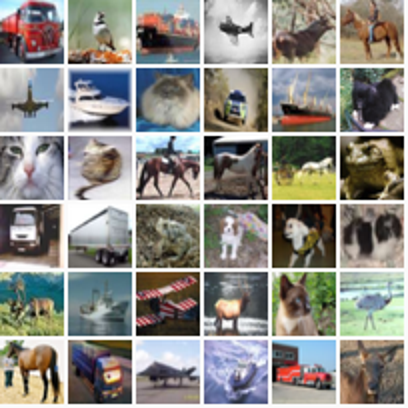

In [ ]:
height_width = 32


def show_collage(examples):
    box_size = height_width + 2
    num_rows, num_cols = examples.shape[:2]

    collage = Image.new(
        mode="RGB",
        size=(num_cols * box_size, num_rows * box_size),
        color=(250, 250, 250),
    )
    for row_idx in range(num_rows):
        for col_idx in range(num_cols):
            array = (np.array(examples[row_idx, col_idx]) * 255).astype(np.uint8)
            collage.paste(
                Image.fromarray(array), (col_idx * box_size, row_idx * box_size)
            )

    # Double size for visualisation.
    collage = collage.resize((2 * num_cols * box_size, 2 * num_rows * box_size))
    return collage


# Show a collage of 5x5 random images.
sample_idxs = np.random.randint(0, 50000, size=(6, 6))
inputs = x_train[sample_idxs]
show_collage(inputs)

Yukarıdaki görseller için tanımlanmış olan cifar10 indeks değerleri (Örnek 3=Kedi)

In [ ]:
outputs = y_train[sample_idxs]
print (outputs)


[[9 2 8 0 4 7]
 [0 8 3 1 8 5]
 [3 3 7 7 7 6]
 [9 9 6 5 5 5]
 [4 8 0 4 3 2]
 [7 9 0 8 9 4]]


Metrik öğrenmede eğitim verisi doğrudan etiketli çiftler yerine, rastgele seçilen bir çapa (anchor) ve aynı sınıftan bir pozitif örnek arasındaki benzerlik ilişkisi üzerinden kurgulanır. Bu süreci yürütmek için sınıfları ilgili örneklerle eşleştiren bir dizin yapısı oluşturulur ve eğitim sırasında veriler bu yapıdan örneklenerek kullanılır.

In [ ]:
class_idx_to_train_idxs = defaultdict(list)
for y_train_idx, y in enumerate(y_train):
    class_idx_to_train_idxs[y].append(y_train_idx)

class_idx_to_test_idxs = defaultdict(list)
for y_test_idx, y in enumerate(y_test):
    class_idx_to_test_idxs[y].append(y_test_idx)


Kedi görsellerinin olduğu indeksler için 3 sayısı (ilk 5 tanesini göstersin)

In [ ]:
print(class_idx_to_train_idxs[3][:5])

[9, 17, 21, 26, 33]


Eğitim sürecinde her sınıftan birer adet olmak üzere oluşturulan (çapa, pozitif) çiftleri, aynı kümedeki diğer örneklerden uzaklaştırılıp birbirine yaklaştırılmaya çalışılır. Bu yöntemde veri paketinin (batch) boyutu doğrudan sınıf sayısına bağlıdır; örneğin CIFAR-10 veri kümesi için bu sayı 10 olarak belirlenir.

In [ ]:
num_classes = 10


class AnchorPositivePairs(keras.utils.Sequence):
    def __init__(self, num_batches):
        super().__init__()
        self._num_batches = num_batches

    def __len__(self):
        return self._num_batches

    def __getitem__(self, _idx):
        x = np.empty((2, num_classes, height_width, height_width, 3), dtype=np.float32)
        for class_idx in range(num_classes):
            examples_for_class = class_idx_to_train_idxs[class_idx]
            anchor_idx = random.choice(examples_for_class)
            positive_idx = random.choice(examples_for_class)
            while positive_idx == anchor_idx:
                positive_idx = random.choice(examples_for_class)
            x[0, class_idx] = x_train[anchor_idx]
            x[1, class_idx] = x_train[positive_idx]
        return x


Oluşturulan veri paketini bir kolaj yardımıyla görselleştirmek mümkündür. Bu görselde üst satır, on farklı sınıftan rastgele seçilmiş çapa (anchor) örneklerini, alt satır ise bunlara karşılık gelen on pozitif örneği gösterir.
Uçak, Araba, Kuş, Kedi, Geyik, Köpek, Kurbaa, At, Gemi, Kamyon

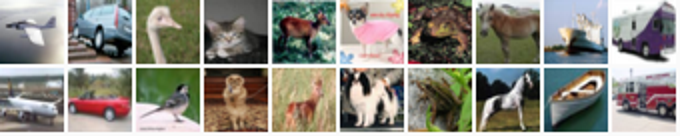

In [ ]:
inputs = next(iter(AnchorPositivePairs(num_batches=1)))

show_collage(inputs)

Tanımlanan bu modelin eğitim adımında (train_step), öncelikle çapa ve pozitif örneklerin sayısal vektör karşılıkları (embedding) oluşturulur. Ardından, bu vektörlerin birbirleriyle olan nokta çarpımları (dot product) hesaplanarak, benzerlik skorlarını belirleyen bir softmax katmanı için girdi (logits) olarak kullanılır.

In [ ]:
class EmbeddingModel(keras.Model):
    def train_step(self, data):
        # Not: Açık soruna yönelik geçici çözüm kaldırılacaktır.
        if isinstance(data, tuple):
            data = data[0]
        anchors, positives = data[0], data[1]

        with tf.GradientTape() as tape:
            # Hem çapraz hem de pozitif değerleri model üzerinden geçirir.

            anchor_embeddings = self(anchors, training=True)
            positive_embeddings = self(positives, training=True)

            # Çapa noktaları ve pozitif noktalar arasındaki kosinüs benzerliğini hesaplar.
            # Normalleştirildikleri için bu sadece ikili nokta çarpımlarıdır.

            benzerlik = keras.ops.einsum(
                "ae,pe->ap", anchor_embeddings, positive_embeddings
            )

            # Bunları logit olarak kullanmayı planladığımız için, bunları bir katsayıyla ölçeklendiriyoruz.
            # Bu değer normalde bir hiper parametre olarak seçilir. temperature olarak geçiyor literaturde.

            katsayi = 0.2
            benzerlik /= katsayi

            # Çapa/pozitif çiftlere karşılık gelen ana diyagonal değerlerin yüksek olması isteniyor.
            # Bu kayıp, çapa/pozitif çiftler için gömülü vektörleri birbirine yaklaştıracak ve
            # diğer tüm çiftleri birbirinden uzaklaştıracaktır.

            sparse_labels = keras.ops.arange(num_classes)
            loss = self.compute_loss(y=sparse_labels, y_pred= benzerlik)

        # Eğimleri hesaplar ve optimizasyon algoritması aracılığıyla uygular.

        gradients = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_variables))

        # Güncellemeleri yapar ve ölçüm değerlerini (özellikle kayıp değeriyle ilgili olanı) döndürür.
        for metric in self.metrics:

            if metric.name == "loss":
                metric.update_state(loss)
            else:
                metric.update_state(sparse_labels, benzerlik)

        return {m.name: m.result() for m in self.metrics}



Görüntüleri vektör uzayına aktaran bu model; evrişimli katmanlar (CNN), global havuzlama ve doğrusal bir projeksiyon katmanından oluşur. Benzerlik hesaplamasını kolaylaştırmak için vektörler normalize edilir ve model yapısı basitlik adına küçük tutulmuştur.

In [ ]:
inputs = layers.Input(shape=(height_width, height_width, 3))
x = layers.Conv2D(filters=32, kernel_size=3, strides=2, activation="relu")(inputs)
x = layers.Conv2D(filters=64, kernel_size=3, strides=2, activation="relu")(x)
x = layers.Conv2D(filters=128, kernel_size=3, strides=2, activation="relu")(x)
x = layers.GlobalAveragePooling2D()(x)

embeddings = layers.Dense(units=8, activation=None)(x)
embeddings = layers.UnitNormalization()(embeddings)

model = EmbeddingModel(inputs, embeddings)

Son olarak eğitimi başlatıyoruz. Google Colab (CPU 5 dakika) GPU örneğinde 1 dakika sürüyor.

Epoch 1/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 2.2283
Epoch 2/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 2.0876
Epoch 3/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 2.0266
Epoch 4/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.9812
Epoch 5/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.9376
Epoch 6/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.9063
Epoch 7/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1.8669
Epoch 8/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.8455
Epoch 9/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.8121
Epoch 10/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.7962
Epoch 11/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 1.7643
Epoch 12/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.7361
Epoch 13/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.7218
Epoch 14/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.7007
Epoch 15/20
1000/1000 ━━━━━━━

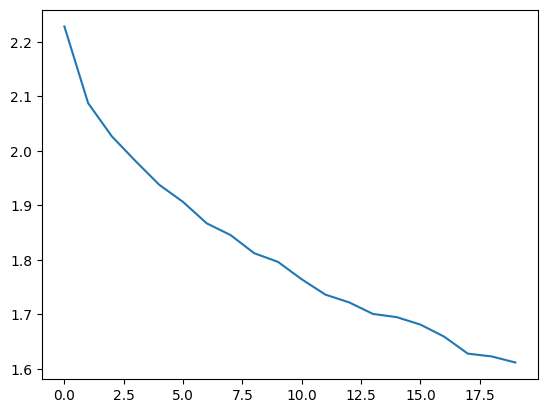

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
)

history = model.fit(AnchorPositivePairs(num_batches=1000), epochs=20)

plt.plot(history.history["loss"])
plt.show()

Öncelikle test kümesini gömüyoruz ve tüm yakın komşuları hesaplıyoruz. Gömme işlemlerinin birim uzunlukta olduğunu hatırlarsak, nokta çarpımları yoluyla kosinüs benzerliğini hesaplayabiliriz.

In [ ]:
near_neighbours_per_example = 10

embeddings = model.predict(x_test)
gram_matrix = np.einsum("ae,be->ab", embeddings, embeddings)
near_neighbours = np.argsort(gram_matrix.T)[:, -(near_neighbours_per_example + 1) :]


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


Gömülü vektörlerin (embeddings) başarısını görsel olarak denetlemek için, rastgele seçilen 8 örnek ve bunların en yakın komşularından oluşan bir kolaj oluşturuldu. Bu görselde ilk sütun hedef görüntüyü, sonraki 10 sütun ise benzerlik sırasına göre dizilmiş en yakın komşuları temsil eder.

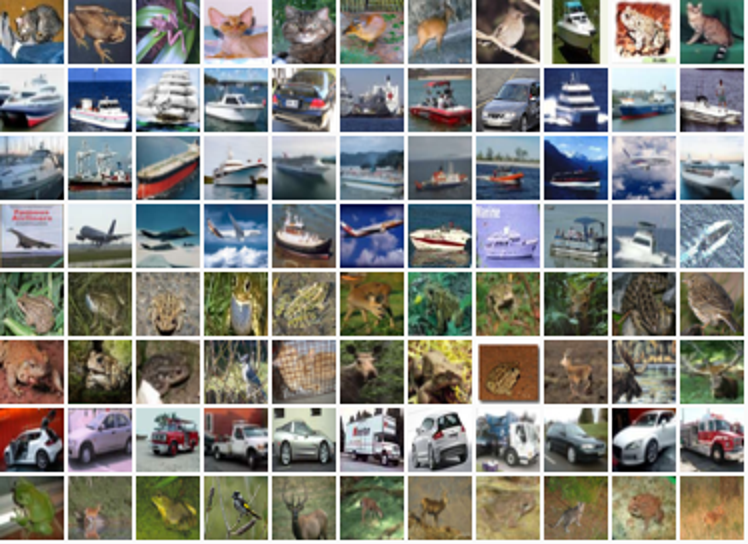

In [ ]:
num_collage_examples = 8

examples = np.empty(
    (
        num_collage_examples,
        near_neighbours_per_example + 1,
        height_width,
        height_width,
        3,
    ),
    dtype=np.float32,
)
for row_idx in range(num_collage_examples):
    examples[row_idx, 0] = x_test[row_idx]
    anchor_near_neighbours = reversed(near_neighbours[row_idx][:-1])
    for col_idx, nn_idx in enumerate(anchor_near_neighbours):
        examples[row_idx, col_idx + 1] = x_test[nn_idx]

show_collage(examples)


Performans analizi için her sınıftan on örnek seçilip yakın komşularının aynı sınıfa ait olup olmadığına bakılarak bir karışıklık matrisi (confusion matrix) oluşturulur. Gözlemler sonucunda hayvan ve araç sınıflarının kendi içlerinde yüksek doğruluk sergilediği, hataların ise genellikle benzer kategoriler (hayvanların hayvanlarla, araçların araçlarla) arasında yaşandığı görülür.

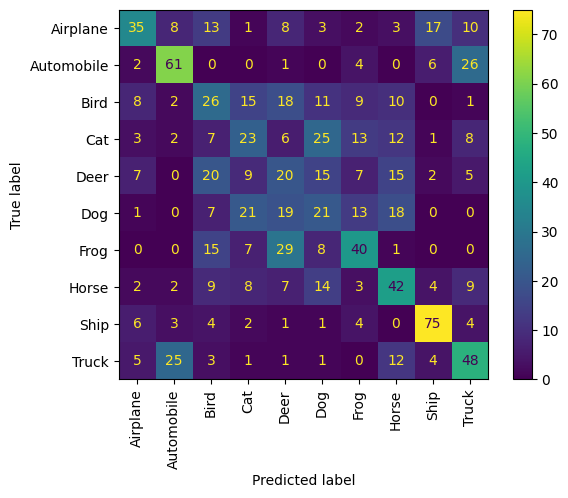

In [ ]:

confusion_matrix = np.zeros((num_classes, num_classes))

# For each class.
for class_idx in range(num_classes):
    # Consider 10 examples.
    example_idxs = class_idx_to_test_idxs[class_idx][:10]
    for y_test_idx in example_idxs:
        # And count the classes of its near neighbours.
        for nn_idx in near_neighbours[y_test_idx][:-1]:
            nn_class_idx = y_test[nn_idx]
            confusion_matrix[class_idx, nn_class_idx] += 1

# Display a confusion matrix.
labels = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck",
]
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=labels)
disp.plot(include_values=True, cmap="viridis", ax=None, xticks_rotation="vertical")
plt.show()

In [ ]:
from google.colab import files

print("Lütfen denemek istediğiniz resimleri seçin:")
uploaded = files.upload()


labels = [
    "Airplane (Uçak)", "Automobile (Otomobil)", "Bird (Kuş)", "Cat (Kedi)",
    "Deer (Geyik)", "Dog (Köpek)", "Frog (Kurbağa)", "Horse (At)",
    "Ship (Gemi)", "Truck (Kamyon)"
]

def process_and_predict(img_path, model, test_embeddings, y_test):
    img = Image.open(img_path).convert('RGB').resize((32, 32))
    img_array = np.array(img).astype('float32') / 255.0
    img_tensor = np.expand_dims(img_array, axis=0)

    target_embedding = model.predict(img_tensor, verbose=0)

    similarities = np.dot(target_embedding, test_embeddings.T)

    closest_idx = np.argmax(similarities)
    predicted_class = y_test[closest_idx]

    return img, labels[predicted_class]


test_embeddings = model.predict(x_test, verbose=0)
plt.figure(figsize=(10, 10))
num_uploaded_items = len(uploaded.items())

num_cols = int(np.ceil(num_uploaded_items / 2.0)) if num_uploaded_items > 0 else 1
num_rows = 2 if num_uploaded_items > 2 else 1 # Eğer 2'den fazla resim varsa 2 satır, yoksa 1

for i, (filename, content) in enumerate(uploaded.items()):
    pil_img, result_text = process_and_predict(filename, model, test_embeddings, y_test)

    plt.subplot(num_rows, num_cols, i + 1)
    plt.imshow(pil_img)
    plt.title(f"Tahmin: {result_text}\n({filename})")
    plt.axis('off')

plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'google'